Transformer model with 5 feature (Open, High, Low, Close, Volume)

Target: Future Close Price

Most recently hypertuned on 17-03-2026

Importing all the necessary Libraries

In [1]:
#Standard library
import os
import random
from datetime import datetime, timedelta

#Data manipulation and numerical computing
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [2]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

Code to fetch and download data (Apple Stock Price) from Yahoo Finance every week day roughly for the past 10 years

In [ ]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end="2026-03-16")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

#Defining a list that only contains column names of the feature I will use to train my model
price_features = ['Close', 'Open', 'High', 'Low', 'Volume']

#.values convert the array into a numpy array (multi-dimensional array) - which is common when using neural networks
feature_data = data[price_features].astype(np.float32).values

#Storing timestamps (which are useful for plotting/alignment later)
datetime_index = data['Date'].values

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_40296\2131163784.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2026-03-16")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2015-01-02,24.214893,24.682226,23.776353,24.671151,212818400
1,2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000
2,2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
3,2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
4,2015-01-08,24.781895,24.839481,24.075359,24.192747,237458000


In [4]:
#Get the number of close prices
print(f"Number of close prices: {len(data)}")

Number of close prices: 2815


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [5]:
total_size = len(feature_data)

#Defining the split size
#70% of the total data to be used for training, 15% for validation, and 15% for testing
train_size = int(len(feature_data) * 0.70)
val_size   = int(len(feature_data) * 0.15)

#Chronogically splitting the data so first 70% is training, the next 15% is validation and the remaining 15% is testing
train_data = feature_data[:train_size] #gets items from 0 to 69
val_data = feature_data[train_size:train_size + val_size] #gets items from 69 to 84
test_data = feature_data[train_size + val_size:] #gets items from 85 to 99

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_data)} samples ({len(train_data)/total_size:.2%})")
print(f"Validation set : {len(val_data)} samples ({len(val_data)/total_size:.2%})")
print(f"Test set       : {len(test_data)} samples ({len(test_data)/total_size:.2%})")

print("Train:", train_data.shape)
print("Val  :", val_data.shape)
print("Test :", test_data.shape)

print("\nCheck sum:", len(train_data) + len(val_data) + len(test_data))

Total samples: 2815

Dataset sizes:
Training set   : 1970 samples (69.98%)
Validation set : 422 samples (14.99%)
Test set       : 423 samples (15.03%)
Train: (1970, 5)
Val  : (422, 5)
Test : (423, 5)

Check sum: 2815


Normalizing the data using a Min-Max Scaler. But only using only the training data as the scaler to prevent data leaks. 

In [6]:
#Calculating the number of features, and creating a seperate scaler for each feature
num_features = train_data.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

#Fit each scaler on only the training data for that specific column - this avoids data leaks
#Here we just calculate and store the min and max values for each feature
for i, scaler in enumerate(scalers):
    scaler.fit(train_data[:, [i]]) #gets all rows, and just spefific columns - for each feature

#Transform each column individually using its corresponding scaler
#Transforming means actually applying the MinMax formula to get new values between 0-1
#np.hstack then stacks the scaled columns back together horizontally
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#All three datasets are transformed using the scalers fitted on the training data
train_scaled = scale_data(train_data, scalers)
val_scaled = scale_data(val_data, scalers)
test_scaled = scale_data(test_data, scalers)

print("Train scaled min/max:", train_scaled.min(), train_scaled.max())
print("Val   scaled min/max:", val_scaled.min(), val_scaled.max())
print("Test  scaled min/max:", test_scaled.min(), test_scaled.max())

Train scaled min/max: 0.0 1.0
Val   scaled min/max: -0.027889103 1.295198
Test  scaled min/max: -0.037986904 1.6957202


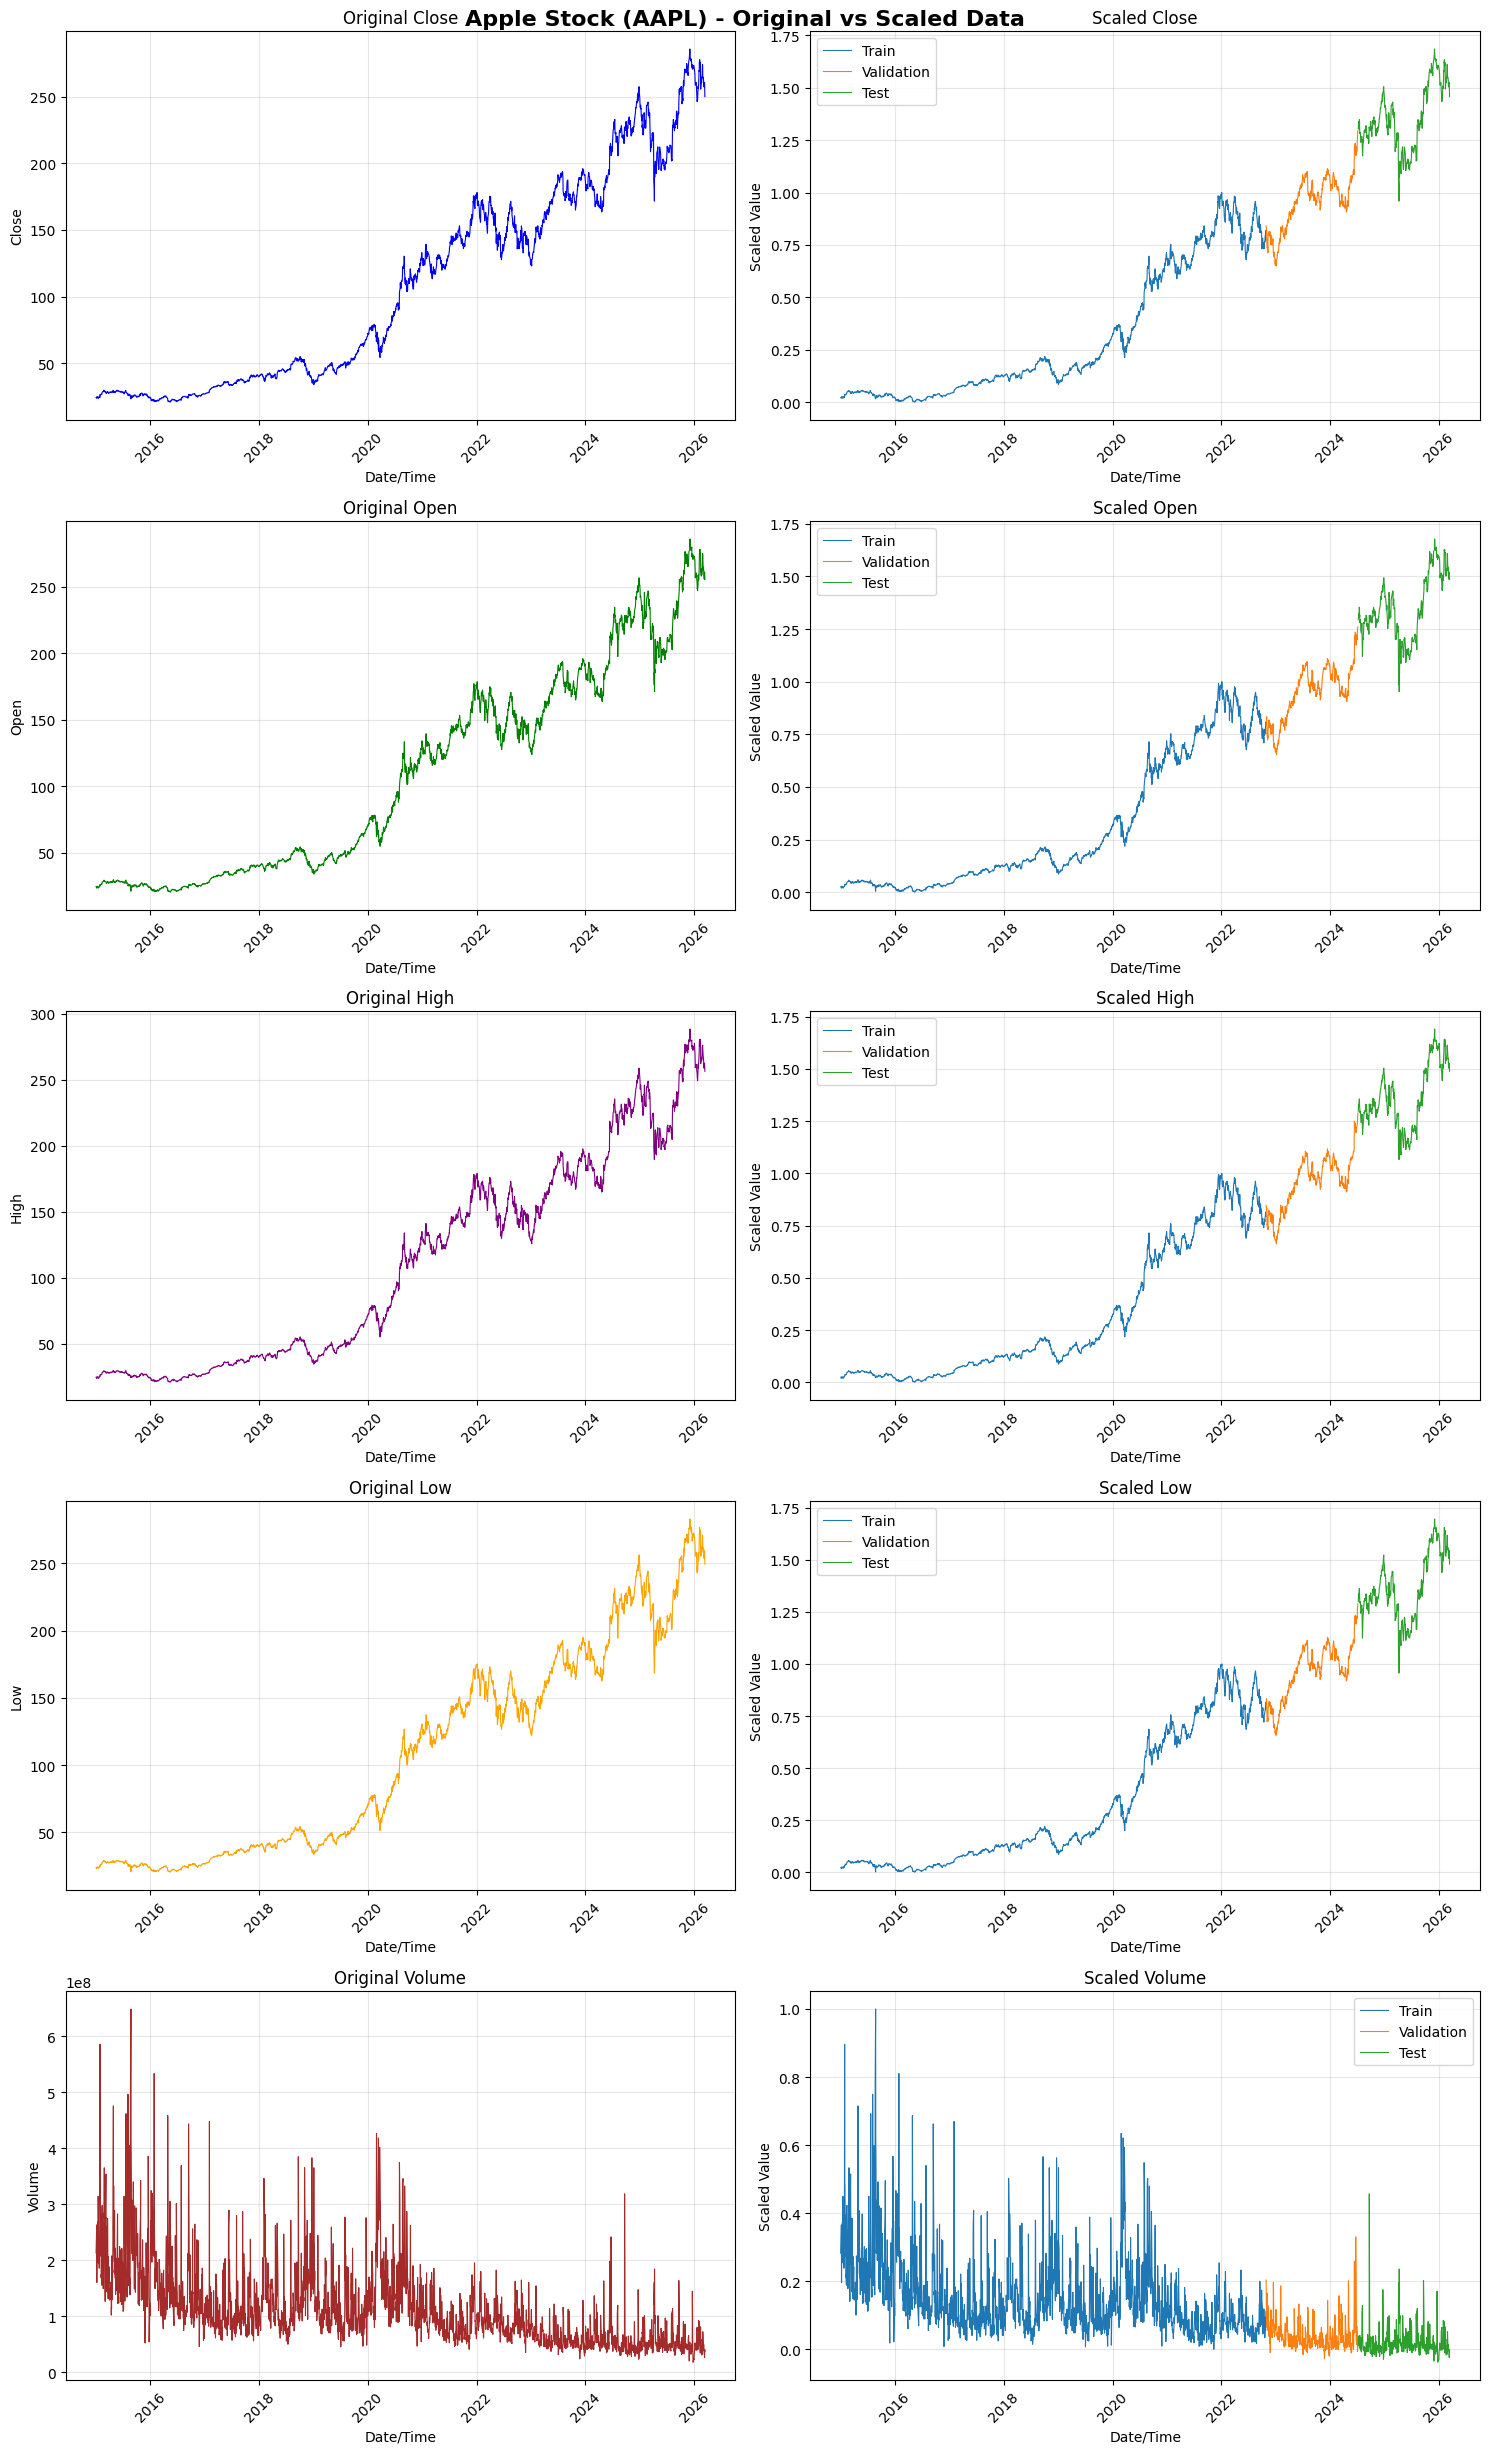

In [7]:
#Here we split the dateime index to match the training/valiation and test data splits.
#To ensure each data segment has corresponding timestamps for plotting
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_data.shape[1]

#Here we create the grid subplots as per the number of features we want to feed into our model 
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume']
colors = ['blue', 'green', 'purple', 'orange', 'brown']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, feature_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

Creating a Sliding Window to feed inputs to my model

In [8]:
def create_multifeature_dataset_with_context(data, time_step, context_data = None):

    if context_data is not None:
        data = np.vstack([context_data[-time_step:], data])

    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  #here we grab all columns and rows per timesteps (rows 0-24 first time)
        y.append(data[i + time_step, 0])  #here we only predict the Close price (row 25)

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 25

X_train, y_train = create_multifeature_dataset_with_context(train_scaled, time_step)
X_val, y_val     = create_multifeature_dataset_with_context(val_scaled, time_step, context_data=train_scaled)
X_test, y_test   = create_multifeature_dataset_with_context(test_scaled, time_step, context_data=val_scaled)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")


Shapes of LSTM datasets:
X_train: (1945, 25, 5), y_train: (1945,)
X_val  : (422, 25, 5), y_val  : (422,)
X_test : (423, 25, 5), y_test : (423,)


Positional Encoding Function:
Used to provide the model with extra information about time steps as self-attetion alone doesn't know sequence order

In [9]:
class LearnablePositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, time_step, d_model):
        super().__init__()
        self.supports_masking = True
        
        # Initialize with sinusoidal values instead of random
        initial_pe = self.sinusoidal_init(time_step, d_model)

        self.pos_embedding = self.add_weight(
            shape=(1, time_step, d_model),
            initializer=tf.keras.initializers.Constant(initial_pe),
            trainable=True,
            name="learnable_pos_embedding"
        )

    def sinusoidal_init(self, time_step, d_model):
        pos = np.arange(time_step)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        return angle_rads[np.newaxis, ...]

    def call(self, x):
        return x + tf.cast(self.pos_embedding, x.dtype)

Transformer Model Architecture

In [10]:
#Build the Transformer encoder
num_features = X_train.shape[2]
d_model = 64
num_heads = 2
ff_dim = 128

#Building the input preojection embedding - projecting the original features into a higher-dimensional space
inputs = Input(shape=(time_step, num_features))
x = Dense(d_model)(inputs)

#Add Positional Encoding - now using learned positions
x = LearnablePositionalEncoding(time_step, d_model)(x)


#Building the Transformer Encoder Blocks
for _ in range(2): 

    #Multi-Head Self-Attentio
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x, use_causal_mask=True)
    attn_output = Dropout(0.15)(attn_output)

    #Residual Connection + Layer Norm
    x = LayerNormalization(epsilon=1e-4)(x + attn_output)

    #Feed-Forward Network (FFN)
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(d_model)(ff_output)
    ff_output = Dropout(0.15)(ff_output)

    #Residual Connection + Layer Norm
    x = LayerNormalization(epsilon=1e-4)(x + ff_output)

#Extract the last day for regression and convert it to a single prediction
x = Lambda(lambda x: x[:, -1, :])(x) 
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="linear")(x)

#Comile the model
model = Model(inputs=inputs, outputs=outputs)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5), loss='mean_squared_error', metrics=['MAE'])


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    shuffle=False, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)


Epoch 1/150
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - MAE: 0.2348 - loss: 0.0891 - val_MAE: 0.0685 - val_loss: 0.0063 - learning_rate: 3.0000e-05
Epoch 2/150
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - MAE: 0.1724 - loss: 0.0479 - val_MAE: 0.0431 - val_loss: 0.0032 - learning_rate: 3.0000e-05
Epoch 3/150
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - MAE: 0.1472 - loss: 0.0347 - val_MAE: 0.0684 - val_loss: 0.0062 - learning_rate: 3.0000e-05
Epoch 4/150
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - MAE: 0.1385 - loss: 0.0313 - val_MAE: 0.0795 - val_loss: 0.0079 - learning_rate: 3.0000e-05
Epoch 5/150
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - MAE: 0.1372 - loss: 0.0314
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-05.
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - MAE: 0.1250 - loss: 0.0253 - val_MAE: 0.0581 - val_loss: 0.0048 - learning_rate: 3.0000e-05
Epoch 6/150
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - MAE: 0.1224 - loss: 0.0240 - val_MAE: 0.0510 - val_los

A graph to visulzise the training process - to check if the model is overfitting

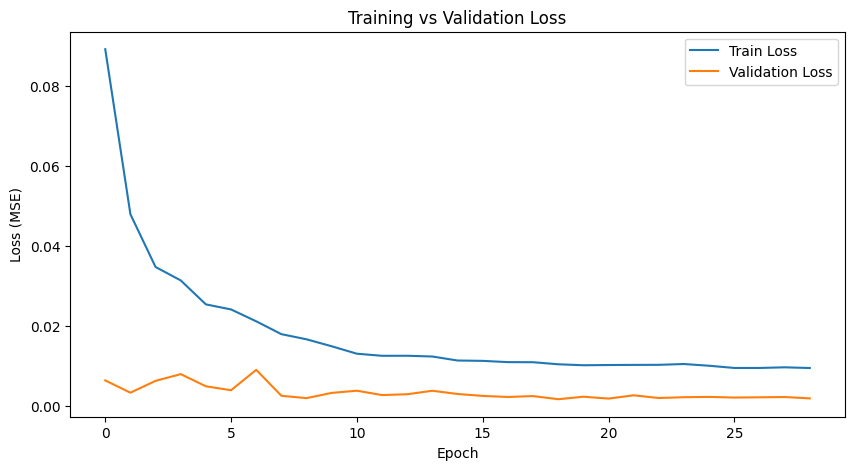

In [11]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predictions

In [12]:
predictions_scaled = model.predict(X_test)

#Inverse transform to get actual dollar values
predictions = scalers[0].inverse_transform(predictions_scaled)
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

#Flatten for easier handling
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

#Calculate metrics

rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
mae  = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE)    : ${mae:.2f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

Unscaled Root Mean Squared Error (RMSE): $5.76
Unscaled Mean Absolute Error (MAE)    : $4.49


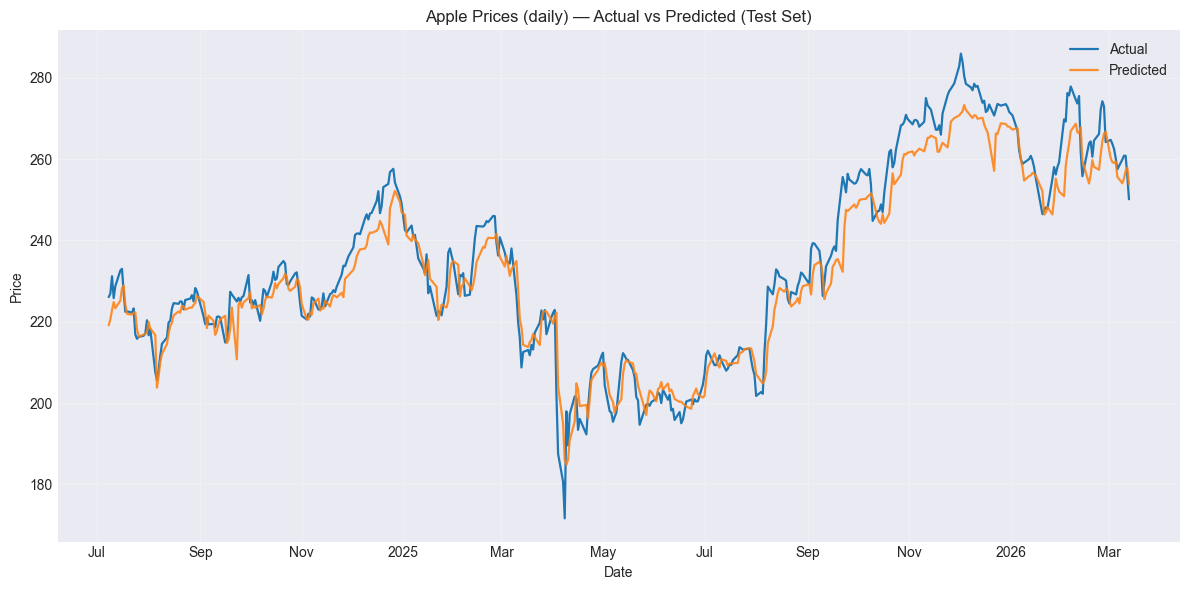

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dates_test = datetime_index[-len(predictions):]

#Plot Actual vs Predicted
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled, label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions, label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.xlabel("Date")
plt.legend()

# Format dates nicely
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Checking the Accuracy of my model:

In [14]:
# --- Directional Accuracy ---

# Actual and predicted price changes
actual_direction = np.sign(np.diff(y_test_unscaled))
predicted_direction = np.sign(np.diff(predictions))

# Directional accuracy
directional_accuracy = np.mean(actual_direction == predicted_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%") 

Directional Accuracy: 50.00%


In [15]:
# --- MAPE-based Accuracy ---

mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100
accuracy_mape = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"MAPE-based Accuracy: {accuracy_mape:.2f}%")

MAPE: 1.89%
MAPE-based Accuracy: 98.11%
